In [1]:
import yfinance as yf
import datetime as d
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
s = d.datetime(2025,1,1)
e = d.datetime(2026,6,1)

In [3]:
all_data = []

In [4]:
stocks_by_country = {

    "USA" : {
    "Apple":"AAPL",
    "Microsoft":"MSFT",
    "NVIDIA":"NVDA",
    "Amazon":"AMZN",
    "Alphabet":"GOOGL",
    "Meta":"META",
    "Tesla":"TSLA",
    "Berkshire Hathaway":"BRK-B",
    "JPMorgan Chase":"JPM",
    "Visa":"V",
    "Mastercard":"MA",
    "UnitedHealth":"UNH",
    "Exxon Mobil":"XOM",
    "Johnson & Johnson":"JNJ",
    "Walmart":"WMT",
    "Procter & Gamble":"PG",
    "Coca-Cola":"KO",
    "McDonalds":"MCD",
    "Oracle":"ORCL",
    "Netflix":"NFLX"
},

    "India": {
    "Reliance Industries":"RELIANCE.NS",
    "TCS":"TCS.NS",
    "Infosys":"INFY.NS",
    "HDFC Bank":"HDFCBANK.NS",
    "ICICI Bank":"ICICIBANK.NS",
    "State Bank of India":"SBIN.NS",
    "Bharti Airtel":"BHARTIARTL.NS",
    "ITC":"ITC.NS",
    "Larsen & Toubro":"LT.NS",
    "Axis Bank":"AXISBANK.NS",
    "Maruti Suzuki":"MARUTI.NS",
    "Bajaj Finance":"BAJFINANCE.NS",
    "Sun Pharma":"SUNPHARMA.NS",
    "Titan":"TITAN.NS",
    "Asian Paints":"ASIANPAINT.NS",
    "UltraTech Cement":"ULTRACEMCO.NS",
    "Nestle India":"NESTLEIND.NS",
    "Power Grid":"POWERGRID.NS",
    "NTPC":"NTPC.NS",
    "Coal India":"COALINDIA.NS"
},

    "UK": {
    "Shell":"SHEL.L",
    "HSBC":"HSBA.L",
    "BP":"BP.L",
    "Barclays":"BARC.L",
    "GSK":"GSK.L",
    "Unilever":"ULVR.L",
    "AstraZeneca":"AZN.L",
    "Diageo":"DGE.L",
    "Lloyds":"LLOY.L",
    "Rio Tinto":"RIO.L",
    "NatWest":"NWG.L",
    "Prudential":"PRU.L",
    "Compass Group":"CPG.L",
    "British American Tobacco":"BATS.L",
    "Legal & General":"LGEN.L",
    "Aviva":"AV.L",
    "Pearson":"PSON.L",
    "Sage":"SGE.L",
    "Vodafone":"VOD.L",
    "Ocado":"OCDO.L"
},
    "GERMANY":  {
    "SAP":"SAP.DE",
    "Siemens":"SIE.DE",
    "Allianz":"ALV.DE",
    "BMW":"BMW.DE",
    "Mercedes Benz":"MBG.DE",
    "Volkswagen":"VOW3.DE",
    "Deutsche Telekom":"DTE.DE",
    "BASF":"BAS.DE",
    "Bayer":"BAYN.DE",
    "Adidas":"ADS.DE",
    "Porsche":"P911.DE",
    "Henkel":"HEN3.DE",
    "Infineon":"IFX.DE",
    "RWE":"RWE.DE",
    "E.ON":"EOAN.DE",
    "MTU Aero Engines":"MTX.DE",
    "Deutsche Bank":"DBK.DE",
    "Commerzbank":"CBK.DE",
    "Fresenius":"FRE.DE",
    "Symrise":"SY1.DE"
},
    "FRANCE" : {
    "LVMH":"MC.PA",
    "TotalEnergies":"TTE.PA",
    "Loreal":"OR.PA",
    "Sanofi":"SAN.PA",
    "Airbus":"AIR.PA",
    "Schneider Electric":"SU.PA",
    "BNP Paribas":"BNP.PA",
    "AXA":"CS.PA",
    "Danone":"BN.PA",
    "Capgemini":"CAP.PA",
    "EssilorLuxottica":"EL.PA",
    "Orange":"ORA.PA",
    "Vinci":"DG.PA",
    "Saint Gobain":"SGO.PA",
    "Safran":"SAF.PA",
    "Carrefour":"CA.PA",
    "Thales":"HO.PA",
    "Publicis":"PUB.PA",
    "Renault":"RNO.PA",
    "Kering":"KER.PA"
},
    "JAPAN" : {
    "Toyota":"7203.T",
    "Sony":"6758.T",
    "Mitsubishi UFJ":"8306.T",
    "Nintendo":"7974.T",
    "SoftBank":"9984.T",
    "Hitachi":"6501.T",
    "Honda":"7267.T",
    "Panasonic":"6752.T",
    "Nippon Steel":"5401.T",
    "Canon":"7751.T",
    "Keyence":"6861.T",
    "Tokyo Electron":"8035.T",
    "Fast Retailing":"9983.T",
    "KDDI":"9433.T",
    "NTT":"9432.T",
    "Seven & I":"3382.T",
    "Rakuten":"4755.T",
    "Mitsui":"8031.T",
    "Sumitomo":"8053.T",
    "Takeda":"4502.T"
},
    "CANADA" : {
    "Royal Bank":"RY.TO",
    "Toronto Dominion":"TD.TO",
    "Brookfield":"BN.TO",
    "Canadian National Railway":"CNR.TO",
    "Enbridge":"ENB.TO",
    "Canadian Pacific":"CP.TO",
    "Bank of Montreal":"BMO.TO",
    "Shopify":"SHOP.TO",
    "Suncor":"SU.TO",
    "Manulife":"MFC.TO",
    "TC Energy":"TRP.TO",
    "Barrick Gold":"ABX.TO",
    "Sun Life":"SLF.TO",
    "Waste Connections":"WCN.TO",
    "Magna":"MG.TO",
    "Telus":"T.TO",
    "BCE":"BCE.TO",
    "Nutrien":"NTR.TO",
    "Cameco":"CCO.TO",
    "Alimentation Couche-Tard":"ATD.TO"
},
    "AUSTRALIA" : {
    "BHP":"BHP.AX",
    "Commonwealth Bank":"CBA.AX",
    "CSL":"CSL.AX",
    "Westpac":"WBC.AX",
    "ANZ":"ANZ.AX",
    "National Australia Bank":"NAB.AX",
    "Macquarie":"MQG.AX",
    "Woodside":"WDS.AX",
    "Rio Tinto Australia":"RIO.AX",
    "Fortescue":"FMG.AX",
    "Woolworths":"WOW.AX",
    "Telstra":"TLS.AX",
    "QBE":"QBE.AX",
    "Santos":"STO.AX",
    "Origin Energy":"ORG.AX",
    "Transurban":"TCL.AX",
    "Aristocrat":"ALL.AX",
    "Brambles":"BXB.AX",
    "Sonic Healthcare":"SHL.AX",
    "South32":"S32.AX"
},
    "China": {
    "Tencent": "0700.HK",
    "Alibaba": "9988.HK",
    "JD.com": "9618.HK",
    "Baidu": "9888.HK",
    "Meituan": "3690.HK",
    "China Mobile": "0941.HK",
    "Ping An": "2318.HK",
    "ICBC": "1398.HK",
    "Bank of China": "3988.HK",
    "PetroChina": "0857.HK",
    "China Life": "2628.HK",
    "Lenovo": "0992.HK",
    "NetEase": "9999.HK",
    "Xiaomi": "1810.HK",
    "BYD": "1211.HK"
},
    "Hong Kong": {
    "AIA": "1299.HK",
    "Hong Kong Exchanges": "0388.HK",
    "CK Hutchison": "0001.HK",
    "Hang Seng Bank": "0011.HK",
    "Sun Hung Kai": "0016.HK",
    "Galaxy Entertainment": "0027.HK",
    "CLP Holdings": "0002.HK",
    "MTR": "0066.HK",
    "Wharf REIC": "1997.HK",
    "Link REIT": "0823.HK",
    "Sino Land": "0083.HK",
    "Henderson Land": "0012.HK",
    "BOC Hong Kong": "2388.HK",
    "Techtronic": "0669.HK",
    "ASMPT": "0522.HK"
},
    "Singapore": {
    "DBS": "D05.SI",
    "OCBC": "O39.SI",
    "UOB": "U11.SI",
    "Singapore Airlines": "C6L.SI",
    "Singtel": "Z74.SI",
    "CapitaLand": "9CI.SI",
    "Keppel": "BN4.SI",
    "ST Engineering": "S63.SI",
    "Jardine Cycle": "C07.SI",
    "Wilmar": "F34.SI",
    "Thai Beverage": "Y92.SI",
    "Mapletree Logistics": "M44U.SI",
    "Frasers Centrepoint": "J69U.SI",
    "ComfortDelGro": "C52.SI",
    "Venture": "V03.SI"
},
    "South Korea": {
    "Samsung Electronics": "005930.KS",
    "SK Hynix": "000660.KS",
    "LG Energy": "373220.KS",
    "Samsung SDI": "006400.KS",
    "Hyundai Motor": "005380.KS",
    "Kia": "000270.KS",
    "POSCO": "005490.KS",
    "Naver": "035420.KS",
    "Kakao": "035720.KS",
    "Samsung Biologics": "207940.KS",
    "LG Chem": "051910.KS",
    "KB Financial": "105560.KS",
    "Shinhan Financial": "055550.KS",
    "Celltrion": "068270.KS",
    "Doosan": "000150.KS"
},
    "Taiwan": {
    "TSMC": "2330.TW",
    "Foxconn": "2317.TW",
    "MediaTek": "2454.TW",
    "Delta Electronics": "2308.TW",
    "Cathay Financial": "2882.TW",
    "Fubon Financial": "2881.TW",
    "United Micro": "2303.TW",
    "Mega Financial": "2886.TW",
    "CTBC Financial": "2891.TW",
    "EVA Airways": "2618.TW",
    "China Airlines": "2610.TW",
    "Asus": "2357.TW",
    "Acer": "2353.TW",
    "Nan Ya Plastics": "1303.TW",
    "Formosa Plastics": "1301.TW"
},
    "Netherlands": {
    "ASML": "ASML.AS",
    "ING": "INGA.AS",
    "Shell NL": "SHELL.AS",
    "Heineken": "HEIA.AS",
    "Philips": "PHIA.AS",
    "Adyen": "ADYEN.AS",
    "Prosus": "PRX.AS",
    "Akzo Nobel": "AKZA.AS",
    "Ahold Delhaize": "AD.AS",
    "NN Group": "NN.AS",
    "Wolters Kluwer": "WKL.AS",
    "KPN": "KPN.AS",
    "Randstad": "RAND.AS",
    "ASM International": "ASM.AS",
    "BE Semiconductor": "BESI.AS"
},
    "Switzerland": {
    "Nestle": "NESN.SW",
    "Novartis": "NOVN.SW",
    "Roche": "ROG.SW",
    "UBS": "UBSG.SW",
    "Zurich Insurance": "ZURN.SW",
    "ABB": "ABBN.SW",
    "Swiss Re": "SREN.SW",
    "Holcim": "HOLN.SW",
    "Richemont": "CFR.SW",
    "Lonza": "LONN.SW",
    "Partners Group": "PGHN.SW",
    "Swiss Life": "SLHN.SW",
    "Geberit": "GEBN.SW",
    "Logitech": "LOGN.SW",
    "SGS": "SGSN.SW"
},
    "Sweden": {
    "Volvo": "VOLV-B.ST",
    "Atlas Copco": "ATCO-A.ST",
    "Investor AB": "INVE-B.ST",
    "Ericsson": "ERIC-B.ST",
    "Sandvik": "SAND.ST",
    "SEB": "SEB-A.ST",
    "Handelsbanken": "SHB-A.ST",
    "SKF": "SKF-B.ST",
    "Essity": "ESSITY-B.ST",
    "Hexagon": "HEXA-B.ST",
    "Boliden": "BOL.ST",
    "Securitas": "SECU-B.ST",
    "Tele2": "TEL2-B.ST",
    "Electrolux": "ELUX-B.ST",
    "Alfa Laval": "ALFA.ST"
},
    "Italy": {
    "Enel": "ENEL.MI",
    "Eni": "ENI.MI",
    "Intesa Sanpaolo": "ISP.MI",
    "UniCredit": "UCG.MI",
    "Ferrari": "RACE.MI",
    "Generali": "G.MI",
    "Pirelli": "PIRC.MI",
    "Leonardo": "LDO.MI",
    "Terna": "TRN.MI",
    "Moncler": "MONC.MI",
    "Mediobanca": "MB.MI",
    "Fineco": "FBK.MI",
    "A2A": "A2A.MI",
    "Banca Mediolanum": "BMED.MI",
    "Campari": "CPR.MI"
},
    "Spain": {
    "Inditex": "ITX.MC",
    "Santander": "SAN.MC",
    "BBVA": "BBVA.MC",
    "Iberdrola": "IBE.MC",
    "Telefonica": "TEF.MC",
    "Repsol": "REP.MC",
    "Amadeus": "AMS.MC",
    "Ferrovial": "FER.MC",
    "Naturgy": "NTGY.MC",
    "Aena": "AENA.MC",
    "Cellnex": "CLNX.MC",
    "Acciona": "ANA.MC",
    "Bankinter": "BKT.MC",
    "Mapfre": "MAP.MC",
    "Merlin Properties": "MRL.MC"
},
    "Brazil": {
    "Petrobras": "PETR4.SA",
    "Vale": "VALE3.SA",
    "Itau Unibanco": "ITUB4.SA",
    "Banco Bradesco": "BBDC4.SA",
    "Ambev": "ABEV3.SA",
    "WEG": "WEGE3.SA",
    "Santander Brasil": "SANB11.SA",
    "BTG Pactual": "BPAC11.SA",
    "Suzano": "SUZB3.SA",
    "JBS": "JBSS3.SA",
    "Localiza": "RENT3.SA",
    "Raia Drogasil": "RADL3.SA",
    "TIM Brasil": "TIMS3.SA",
    "Embraer": "EMBR3.SA",
    "Klabin": "KLBN11.SA"
},
    "Saudi Arabia": {
    "Saudi Aramco": "2222.SR",
    "Al Rajhi Bank": "1120.SR",
    "SABIC": "2010.SR",
    "STC": "7010.SR",
    "Saudi National Bank": "1180.SR",
    "Maaden": "1211.SR",
    "ACWA Power": "2082.SR",
    "Riyad Bank": "1010.SR",
    "Alinma Bank": "1150.SR",
    "Sulaiman Al Habib": "4013.SR",
    "Saudi Electricity": "5110.SR",
    "Jarir": "4190.SR",
    "Yanbu Cement": "3060.SR",
    "Mobily": "7020.SR",
    "Savola": "2050.SR"
}

}

In [5]:
for country, stocks in stocks_by_country.items():
    for stock_name, ticker in stocks.items():
        
        df = yf.download(
            ticker,
            start=s,
            end=e,
            progress=False
        )

        df.columns = df.columns.get_level_values(0)
        df = df.reset_index()

        df["Stock_Name"] = stock_name
        df["Ticker"] = ticker
        df["Country"] = country

        all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 0011.HK"}}}
$0011.HK: possibly delisted; no timezone found

1 Failed download:
['0011.HK']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ROG.SW"}}}
$ROG.SW: possibly delisted; no timezone found

1 Failed download:
['ROG.SW']: possibly delisted; no timezone found
$JBSS3.SA: possibly delisted; no timezone found

1 Failed download:
['JBSS3.SA']: possibly delisted; no timezone found
$EMBR3.SA: possibly delisted; no timezone found

1 Failed download:
['EMBR3.SA']: possibly delisted; no timezone found


In [6]:
final_df = final_df.drop(columns=["Adj Close"])
final_df

Price,Date,Close,High,Low,Open,Volume,Stock_Name,Ticker,Country
0,2025-01-02,242.301926,247.518596,240.284814,247.349662,55740700.0,Apple,AAPL,USA
1,2025-01-03,241.815033,242.629819,240.354364,241.815033,40244100.0,Apple,AAPL,USA
2,2025-01-06,243.444611,245.759820,241.656035,242.758989,45045600.0,Apple,AAPL,USA
3,2025-01-07,240.672348,243.991141,239.817807,241.437449,40856000.0,Apple,AAPL,USA
4,2025-01-08,241.159210,242.162808,238.526040,240.384163,37628900.0,Apple,AAPL,USA
...,...,...,...,...,...,...,...,...,...
117879,2026-05-25,28.719999,28.719999,28.719999,28.719999,0.0,Savola,2050.SR,Saudi Arabia
117880,2026-05-26,28.719999,28.719999,28.719999,28.719999,0.0,Savola,2050.SR,Saudi Arabia
117881,2026-05-27,28.719999,28.719999,28.719999,28.719999,0.0,Savola,2050.SR,Saudi Arabia
117882,2026-05-28,28.719999,28.719999,28.719999,28.719999,0.0,Savola,2050.SR,Saudi Arabia


In [ ]:
import os

print(os.getcwd())


C:\Users\Asus


In [11]:
final_df.to_csv("C:\\Users\\Asus\\Desktop\\projects\\Global-Stock-Dashboard\\combined_data\\final_data.csv", index=False)

In [14]:
for country in final_df["Country"].unique():

    country_df = final_df[
        final_df["Country"] == country
    ]

    country_df.to_csv(
        f"C:\\Users\\Asus\\Desktop\\projects\\Global-Stock-Dashboard\\data\\{country}_Final.csv",
        index=False
    )

    print(f"{country}_Final.csv saved")

USA_Final.csv saved
India_Final.csv saved
UK_Final.csv saved
GERMANY_Final.csv saved
FRANCE_Final.csv saved
JAPAN_Final.csv saved
CANADA_Final.csv saved
AUSTRALIA_Final.csv saved
China_Final.csv saved
Hong Kong_Final.csv saved
Singapore_Final.csv saved
South Korea_Final.csv saved
Taiwan_Final.csv saved
Netherlands_Final.csv saved
Switzerland_Final.csv saved
Sweden_Final.csv saved
Italy_Final.csv saved
Spain_Final.csv saved
Brazil_Final.csv saved
Saudi Arabia_Final.csv saved


['USA' 'India' 'UK' 'GERMANY' 'FRANCE' 'JAPAN' 'CANADA' 'AUSTRALIA'
 'China' 'Hong Kong' 'Singapore' 'South Korea' 'Taiwan' 'Netherlands'
 'Switzerland' 'Sweden' 'Italy' 'Spain' 'Brazil' 'Saudi Arabia']
['AIA' 'Hong Kong Exchanges' 'CK Hutchison' 'Sun Hung Kai'
 'Galaxy Entertainment' 'CLP Holdings' 'MTR' 'Wharf REIC' 'Link REIT'
 'Sino Land' 'Henderson Land' 'BOC Hong Kong' 'Techtronic' 'ASMPT']


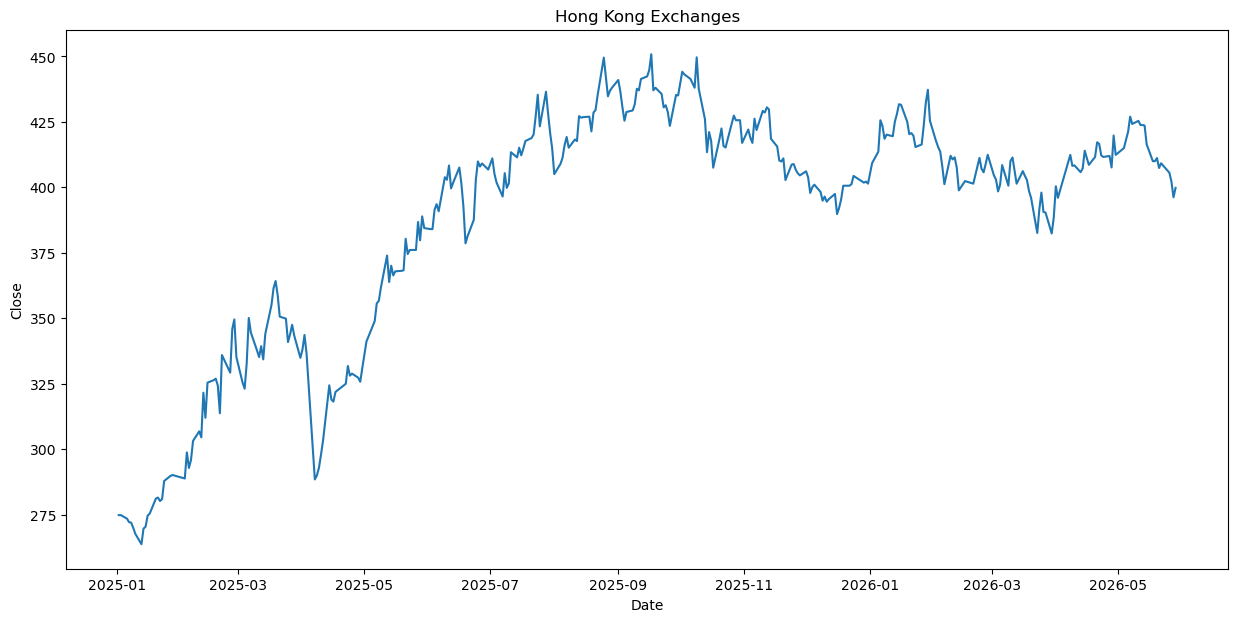

In [15]:
#Demo user Dashboard
print(final_df.Country.unique())

c = input("Entry Sountry name:")
cty = final_df[final_df.Country == c]

print(cty.Stock_Name.unique())
s = input("Enter Stock name:")
st = cty[cty.Stock_Name == s]

plt.figure(figsize=[15,7])
sb.lineplot(x=st.Date,y=st.Close)
plt.title(s)
plt.show()